In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [2]:
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")

In [3]:
df = pd.read_csv("application_train.csv")

In [4]:
df_clean = df.copy()

print("Original Shape :", df.shape)
print("Working Shape  :", df_clean.shape)

Original Shape : (307511, 122)
Working Shape  : (307511, 122)


In [5]:
placeholder_summary  = pd.DataFrame({"Column": ["DAYS_EMPLOYED"],
                                      "Placeholder Values": [365243],
                                      "Count": [(df_clean["DAYS_EMPLOYED"] == 365243).sum()]
                                      })

placeholder_summary

,Column,Placeholder Values,Count
0,DAYS_EMPLOYED,365243,55374


In [6]:
df_clean["DAYS_EMPLOYED"] = df_clean["DAYS_EMPLOYED"].replace(365243,np.nan)

In [7]:
(df_clean["DAYS_EMPLOYED"] ==365243).sum()

np.int64(0)

In [8]:
df_clean.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,252137.000000,...,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,-2384.169325,...,0.008130,0.000595,0.000507,0.000335,0.006402,0.007000,0.034362,0.267395,0.265474,1.899974
std,102790.175348,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,0.013831,4363.988632,2338.360162,...,0.089798,0.024387,0.022518,0.018299,0.083849,0.110757,0.204685,0.916002,0.794056,1.869295
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,189145.500000,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,0.010006,-19682.000000,-3175.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,278202.000000,0.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,0.018850,-15750.000000,-1648.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,367142.500000,0.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,0.028663,-12413.000000,-767.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,456255.000000,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,0.000000,...,1.000000,1.000000,1.000000,1.000000,4.000000,9.000000,8.000000,27.000000,261.000000,25.000000


In [9]:
df_clean.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [10]:
missing_summary = pd.DataFrame({
                    "Column": df_clean.columns,
                    "Missing Count": df_clean.isnull().sum().values,

                    "Missing_percent" : (df_clean.isnull().mean()*100).round(2)
})

missing_summary = (missing_summary.sort_values(by="Missing_percent",
                                               ascending=False))

missing_summary.head(20)


,Column,Missing Count,Missing_percent
COMMONAREA_AVG,COMMONAREA_AVG,214865,69.87
COMMONAREA_MODE,COMMONAREA_MODE,214865,69.87
COMMONAREA_MEDI,COMMONAREA_MEDI,214865,69.87
NONLIVINGAPARTMENTS_MEDI,NONLIVINGAPARTMENTS_MEDI,213514,69.43
NONLIVINGAPARTMENTS_MODE,NONLIVINGAPARTMENTS_MODE,213514,69.43
NONLIVINGAPARTMENTS_AVG,NONLIVINGAPARTMENTS_AVG,213514,69.43
FONDKAPREMONT_MODE,FONDKAPREMONT_MODE,210295,68.39
LIVINGAPARTMENTS_AVG,LIVINGAPARTMENTS_AVG,210199,68.35
LIVINGAPARTMENTS_MEDI,LIVINGAPARTMENTS_MEDI,210199,68.35
LIVINGAPARTMENTS_MODE,LIVINGAPARTMENTS_MODE,210199,68.35


In [11]:
def classify_missing(percent):

    if percent == 0:
        return "No Missing"
    
    elif percent < 5:
        return "low"
    
    elif percent < 20:
        return "Moderate"
    
    elif percent < 50:
        return "High"
    
    else:
        return "Very High"
    
missing_summary["Category"] = (missing_summary["Missing_percent"].apply(classify_missing))

missing_summary

,Column,Missing Count,Missing_percent,Category
COMMONAREA_AVG,COMMONAREA_AVG,214865,69.87,Very High
COMMONAREA_MODE,COMMONAREA_MODE,214865,69.87,Very High
COMMONAREA_MEDI,COMMONAREA_MEDI,214865,69.87,Very High
NONLIVINGAPARTMENTS_MEDI,NONLIVINGAPARTMENTS_MEDI,213514,69.43,Very High
NONLIVINGAPARTMENTS_MODE,NONLIVINGAPARTMENTS_MODE,213514,69.43,Very High
...,...,...,...,...
FLAG_DOCUMENT_16,FLAG_DOCUMENT_16,0,0.00,No Missing
FLAG_DOCUMENT_15,FLAG_DOCUMENT_15,0,0.00,No Missing
FLAG_DOCUMENT_14,FLAG_DOCUMENT_14,0,0.00,No Missing
FLAG_DOCUMENT_20,FLAG_DOCUMENT_20,0,0.00,No Missing


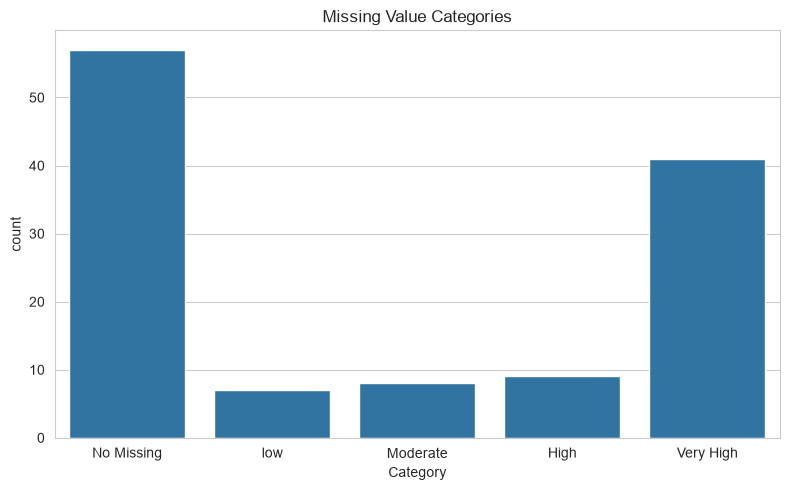

In [12]:
plt.figure(figsize=(8,5))

sns.countplot(
    data = missing_summary,
    x = "Category",
    order=[
        "No Missing",
        "low",
        "Moderate",
        "High",
        "Very High"
    ]
)

plt.title("Missing Value Categories")

plt.tight_layout()

plt.show()

In [13]:
strategy = []

for col in df_clean.columns:

    missing_pct = df_clean[col].isnull().mean()*100

    if missing_pct == 0:

        method = "No Action"

    elif df_clean[col].dtype == "object":

        method = "Median"

    strategy.append({

        "Column": col,

        "Missing_percent": round(missing_pct,2),

        "Recommended Strategy": method

    })

strategy_df = pd.DataFrame(strategy)

strategy_df.head(20)

,Column,Missing_percent,Recommended Strategy
0,SK_ID_CURR,0.00,No Action
1,TARGET,0.00,No Action
2,NAME_CONTRACT_TYPE,0.00,No Action
3,CODE_GENDER,0.00,No Action
4,FLAG_OWN_CAR,0.00,No Action
5,FLAG_OWN_REALTY,0.00,No Action
6,CNT_CHILDREN,0.00,No Action
7,AMT_INCOME_TOTAL,0.00,No Action
8,AMT_CREDIT,0.00,No Action
9,AMT_ANNUITY,0.00,No Action


In [14]:
dtype_summary = pd.DataFrame({

    "Column": df_clean.columns,

    "Data Type": df_clean.dtypes.astype(str).values,

    "Unique Values": df_clean.nunique().values,

    "Missing Values": df_clean.isnull().sum().values
})

dtype_summary.head(20)

,Column,Data Type,Unique Values,Missing Values
0,SK_ID_CURR,int64,307511,0
1,TARGET,int64,2,0
2,NAME_CONTRACT_TYPE,object,2,0
3,CODE_GENDER,object,3,0
4,FLAG_OWN_CAR,object,2,0
5,FLAG_OWN_REALTY,object,2,0
6,CNT_CHILDREN,int64,15,0
7,AMT_INCOME_TOTAL,float64,2548,0
8,AMT_CREDIT,float64,5603,0
9,AMT_ANNUITY,float64,13672,12


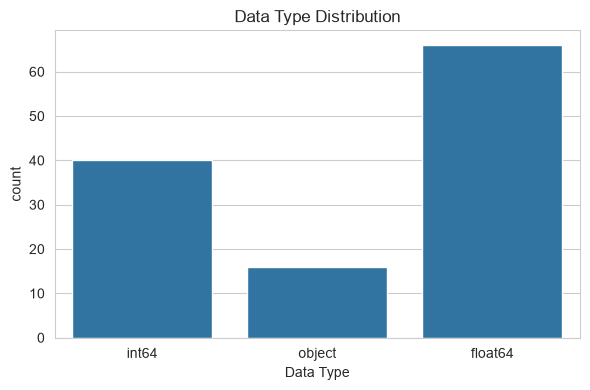

In [15]:
plt.figure(figsize=(6,4))

sns.countplot(
              data=dtype_summary,
              x = "Data Type"
)

plt.title("Data Type Distribution")

plt.tight_layout()

plt.show()

In [16]:
binary_features = [
    col

    for col in df_clean.columns

    if df_clean[col].nunique(dropna=False)==2
]

binary_summary = pd.DataFrame({

    "Binary Feature": binary_features

})

binary_summary

,Binary Feature
0,TARGET
1,NAME_CONTRACT_TYPE
2,FLAG_OWN_CAR
3,FLAG_OWN_REALTY
4,FLAG_MOBIL
5,FLAG_EMP_PHONE
6,FLAG_WORK_PHONE
7,FLAG_CONT_MOBILE
8,FLAG_PHONE
9,FLAG_EMAIL


In [17]:
identifier_summary = pd.DataFrame({

    "Column": df_clean.columns,

    "Unique Values": df_clean.nunique()
})

identifier_summary = identifier_summary[
    identifier_summary["Unique Values"] == len(df_clean)
    ]

identifier_summary

,Column,Unique Values
SK_ID_CURR,SK_ID_CURR,307511


In [18]:
constant_features = [

    col

    for col in df_clean.columns

    if df_clean[col].nunique(dropna=False) ==1
]

constant_df = pd.DataFrame({

    "Constant Features": constant_features
})

constant_df

,Constant Features


In [19]:
near_constant = []

for col in df_clean.columns:

    freq = (
        df_clean[col].value_counts(normalize=True,dropna=False).max()
    )

    if freq > 0.95:

        near_constant.append({

            "Feature": col,

            "Dominant_percent": round(freq*100,2)

        })

near_constant_df = pd.DataFrame(near_constant)

In [20]:
schema_report = pd.DataFrame({

    "Metric":[

        "Rows",

        "Columns",

        "Numeric Columns",

        "Categorical Columns",

        "Binary Features",

        "Constant Features",

        "Identifier Columns"

    ],

    "Value":[

        len(df_clean),

        df_clean.shape[1],

        len(df_clean.select_dtypes(include="number").columns),

        len(df_clean.select_dtypes(include="object").columns),

        len(binary_features),

        len(constant_features),

        len(identifier_summary)

    ]

})

schema_report

,Metric,Value
0,Rows,307511
1,Columns,122
2,Numeric Columns,106
3,Categorical Columns,16
4,Binary Features,36
5,Constant Features,0
6,Identifier Columns,1


In [21]:
duplicate_rows = df_clean.duplicated().sum()

print(f"Duplicated Rows : {duplicate_rows}")

Duplicated Rows : 0


In [22]:
duplicate_customer = df_clean["SK_ID_CURR"].duplicated().sum()

print(f"Duplicate Customer IDs : {duplicate_customer}")

Duplicate Customer IDs : 0


In [23]:
numeric_check = [

    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE"
]

for col in numeric_check:

    invalid = (df_clean[col] < 0).sum()

    print(f"{col} : {invalid}")

AMT_INCOME_TOTAL : 0
AMT_CREDIT : 0
AMT_ANNUITY : 0
AMT_GOODS_PRICE : 0


In [24]:
binary_validation = []

for col in binary_features:

    values = sorted(df_clean[col].dropna().unique())

    binary_validation.append({

        "Feature": col,

        "Values": str(values)
    })

binary_validation_df = pd.DataFrame(binary_validation)

binary_validation_df

,Feature,Values
0,TARGET,"[np.int64(0), np.int64(1)]"
1,NAME_CONTRACT_TYPE,"['Cash loans', 'Revolving loans']"
2,FLAG_OWN_CAR,"['N', 'Y']"
3,FLAG_OWN_REALTY,"['N', 'Y']"
4,FLAG_MOBIL,"[np.int64(0), np.int64(1)]"
5,FLAG_EMP_PHONE,"[np.int64(0), np.int64(1)]"
6,FLAG_WORK_PHONE,"[np.int64(0), np.int64(1)]"
7,FLAG_CONT_MOBILE,"[np.int64(0), np.int64(1)]"
8,FLAG_PHONE,"[np.int64(0), np.int64(1)]"
9,FLAG_EMAIL,"[np.int64(0), np.int64(1)]"


In [25]:
object_summary = pd.DataFrame({

    "Column": df_clean.select_dtypes(include="object").columns,

    "Missing": df_clean.select_dtypes(include="object").isnull().sum().values,

    "Unique" : df_clean.select_dtypes(include="object").nunique().values
})

object_summary

,Column,Missing,Unique
0,NAME_CONTRACT_TYPE,0,2
1,CODE_GENDER,0,3
2,FLAG_OWN_CAR,0,2
3,FLAG_OWN_REALTY,0,2
4,NAME_TYPE_SUITE,1292,7
5,NAME_INCOME_TYPE,0,8
6,NAME_EDUCATION_TYPE,0,5
7,NAME_FAMILY_STATUS,0,6
8,NAME_HOUSING_TYPE,0,6
9,OCCUPATION_TYPE,96391,18


In [26]:
quality_checklist = pd.DataFrame({

    "Validation":[

        "Duplicate Rows",

        "Duplicate Customer IDs",

        "Placeholder Removed",

        "Constant Features Checked",

        "Near Constant Features Checked",

        "Missing Value Strategy Prepared",

        "Data Types Validated"

    ],

    "Status":[

        "Completed",

        "Completed",

        "Completed",

        "Completed",

        "Completed",

        "Completed",

        "Completed"

    ]

})

quality_checklist

,Validation,Status
0,Duplicate Rows,Completed
1,Duplicate Customer IDs,Completed
2,Placeholder Removed,Completed
3,Constant Features Checked,Completed
4,Near Constant Features Checked,Completed
5,Missing Value Strategy Prepared,Completed
6,Data Types Validated,Completed
